<a href="https://colab.research.google.com/github/tsakailab/MultivariateAnalysis/blob/main/ipynb/ex_CA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 例題で理解する対応分析（correspondence analysis）

---
商品と顧客の関係を表すデータの例．類似の商品や，嗜好の似た顧客のグループを見つけよう．

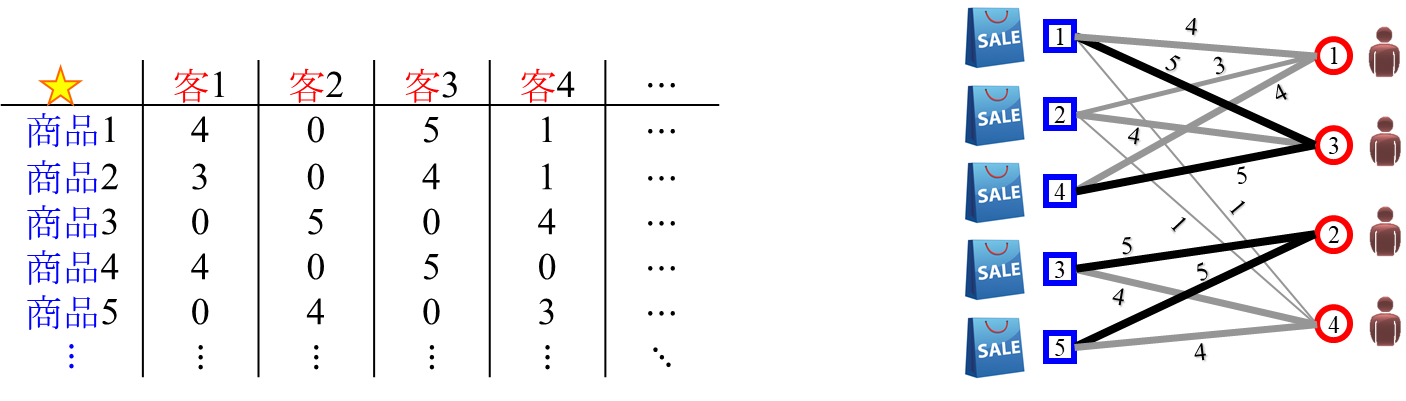

左：分割表（contingency table），右：二部グラフによる表現<br>
（商品と顧客のグループが見やすくなるようにグラフの節を並び替えています）．

---


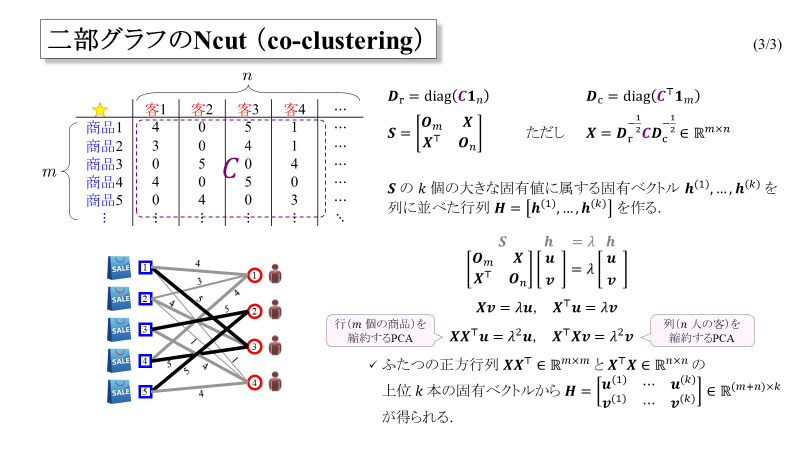

In [ ]:
import numpy as np

# m=5個の商品と，n=4人の顧客の分割表
C = np.array([[     4,      0,      5,      1],
             [     3,      0,      4,      1],
             [     0,      5,      0,      4],
             [     4,      0,      5,      0],
             [     0,      4,      0,      3]])
m, n = C.shape

In [ ]:
dr = C.sum(axis=1)
dc = C.sum(axis=0)
Dr_invsq = np.diag(1.0 / np.sqrt(dr))
Dc_invsq = np.diag(1.0 / np.sqrt(dc))
X = Dr_invsq.dot(C).dot(Dc_invsq)

with np.printoptions(precision=3):
    print("dr = ", dr, "\ndc = ", dc)
    print("Dr^(-1/2) = \n", Dr_invsq)
    print("Dc^(-1/2) = \n", Dc_invsq)
    print("X = \n", X)

In [ ]:
from IPython.display import display, Math

display(Math(r"\boldsymbol{X}\boldsymbol{X}^\top\boldsymbol{u}=\lambda^2\boldsymbol{u}"))
eigval, U = np.linalg.eig(X.dot(X.T))
with np.printoptions(precision=3):
    print("lambda^2 =", eigval)
    print("U.shape = ", U.shape)

display(Math(r"\boldsymbol{X}^\top\boldsymbol{X}\boldsymbol{v}=\lambda^2\boldsymbol{v}"))
eigval, V = np.linalg.eig(X.T.dot(X))
with np.printoptions(precision=3):
    print("lambda^2 =", eigval)
    print("V.shape = ", V.shape)

In [ ]:
display(Math(r"\boldsymbol{H}=\begin{bmatrix}\boldsymbol{u}^{(1)} & \boldsymbol{u}^{(2)}\\ \boldsymbol{v}^{(1)} & \boldsymbol{v}^{(2)}\end{bmatrix}"))
H = np.vstack((U[:,:2], V[:,:2]))
with np.printoptions(precision=3):
    print("H = \n", H)

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(H[:m,0], H[:m,1], c='blue', marker='s')
for i, txt in enumerate(range(1,m+1)):
    plt.text(H[i,0]+0.1, H[i,1], txt, ha='center', c='blue')
plt.xlim(-1,1); plt.ylim(-1,1); plt.gca().set_aspect(1.0)

plt.scatter(H[m:,0], H[m:,1], c='red', marker='o')
for i, txt in enumerate(range(1,n+1)):
    plt.text(H[m+i,0]-0.1, H[m+i,1], txt, ha='center', c='red')
plt.xlim(-1,1); plt.ylim(-1,1); plt.gca().set_aspect(1.0)

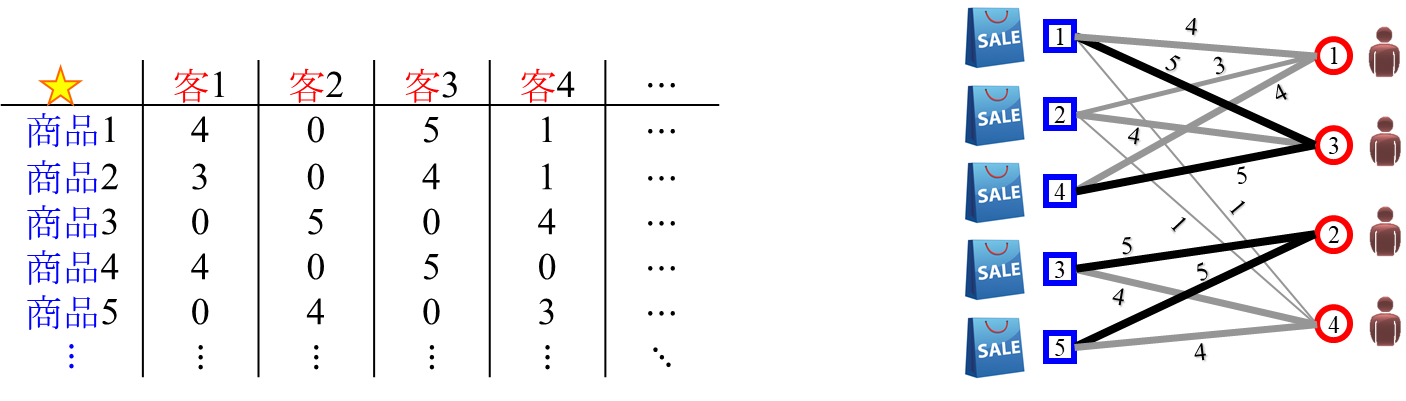

In [ ]:
# scikit-learn の SpectralCoClustering でco-clusteringできます．
from sklearn.cluster import SpectralCoclustering
n_clusters = 2
model = SpectralCoclustering(n_clusters=n_clusters)
model.fit(C)

label_products, label_customers = model.row_labels_, model.column_labels_
for c in range(n_clusters):
    print("Cluster #", c, ": products", np.where(label_products==c)[0]+1, "and customers", np.where(label_customers==c)[0]+1)

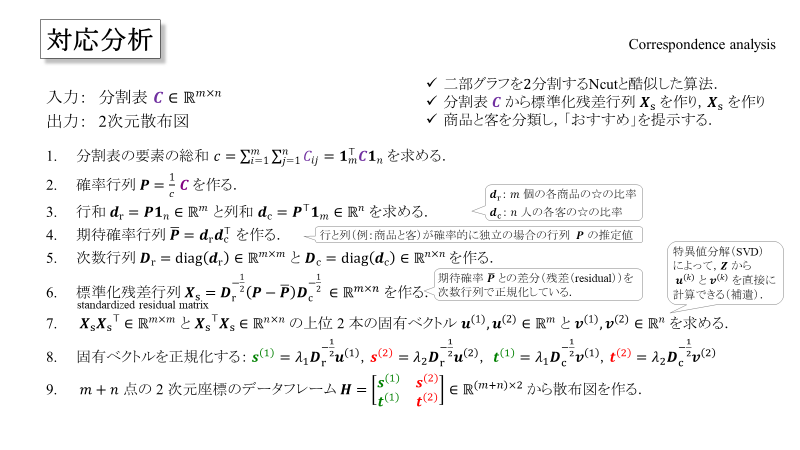

In [ ]:
print("C = \n", C)
P = C / C.sum()

dr = P.sum(axis=1)
dc = P.sum(axis=0)
Ps = np.outer(dr, dc)
Dr_invsq = np.diag(1.0 / np.sqrt(dr))
Dc_invsq = np.diag(1.0 / np.sqrt(dc))
Xs = Dr_invsq.dot(P-Ps).dot(Dc_invsq)

with np.printoptions(precision=3):
    print("P = \n", P)
    print("Ps = \n", Ps)
    print("dr = ", dr, "\ndc = ", dc)
    print("Dr^(-1/2) = \n", Dr_invsq)
    print("Dc^(-1/2) = \n", Dc_invsq)
    print("Xs = \n", Xs)

In [ ]:
U, lam, V = np.linalg.svd(Xs)
with np.printoptions(precision=3):
    print("U = \n", U)
    print("lambda = ", lam)
    print("V = \n", V)

s1s2 = Dr_invsq.dot(U[:,:2])
t1t2 = Dc_invsq.dot(V.T[:,:2])

H = np.vstack((s1s2, t1t2))
H[:,0] *= lam[0]
H[:,1] *= lam[1]

with np.printoptions(precision=3):
    print("H = \n", H)

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(H[:m,0], H[:m,1], c='blue', marker='s')
for i, txt in enumerate(range(1,m+1)):
    plt.text(H[i,0]+0.2, H[i,1], txt, ha='center', c='blue')
plt.xlim(-1,1); plt.ylim(-1,1); plt.gca().set_aspect(1.0)

plt.scatter(H[m:,0], H[m:,1], c='red', marker='o')
for i, txt in enumerate(range(1,n+1)):
    plt.text(H[m+i,0], H[m+i,1]-0.2, txt, ha='center', c='red')
plt.xlim(-2,2); plt.ylim(-2,2); plt.gca().set_aspect(1.0)

In [ ]:
# 対応分析まとめ

import numpy as np

# C は既知のcontingency table
m, n = C.shape

# 1. 確率行列Pを計算
P = C / C.sum()

# 2. 行和dr, 列和dcを計算
dr = P.sum(axis=1)
dc = P.sum(axis=0)

# 3. 期待確率行列Psを計算
Ps = np.outer(dr, dc)

# 4. Dr^(-1/2) と Dc^(-1/2) を計算
Dr_invsq = np.diag(1.0 / np.sqrt(dr))
Dc_invsq = np.diag(1.0 / np.sqrt(dc))

# 5. 標準化残差行列Xsを計算
Xs = Dr_invsq.dot(P - Ps).dot(Dc_invsq)

# 6. Xsの特異値分解（SVD）
U, lam, V = np.linalg.svd(Xs)

# 7. 2次元プロットのための座標 H を計算
# 行の座標 (商品) s1s2
s1s2 = Dr_invsq.dot(U[:, :2])

# 列の座標 (顧客) t1t2
t1t2 = Dc_invsq.dot(V.T[:n, :2])

# 特異値でスケーリング
H = np.vstack((s1s2, t1t2))
H[:, 0] *= lam[0]
H[:, 1] *= lam[1]

with np.printoptions(precision=3):
    print("H = \n", H)
    print("H.shape = ", H.shape)